# Introduction


*Team members*
- Alexandre Dréan (2408681)
- Julien Segonne (2409827)

In [9]:
import pandas as pd
from scipy.io import mmread
import scipy.sparse as sp
import torch
import torch.nn as nn
from torch.optim import Adam
import torch.nn.functional as F
import scipy.sparse as sp
import numpy as np
import ast
import os
import matplotlib.pyplot as plt
import pyarrow.feather as feather
from tqdm import tqdm

### Chargement des données & Fonctions utilitaires

In [39]:
ids = pd.read_csv('data/TP4-ids.csv', index_col=0)
articles = pd.concat([
    pd.read_csv('data/TP4-articles1.csv', index_col=0),
    pd.read_csv('data/TP4-articles2.csv', index_col=0)
], ignore_index=True)
ids_test = pd.read_csv('data/TP4-ids-test.csv', index_col=0)
adjacency = mmread('data/TP4-matrice-adjacence.dgt').tocsr() # Shape : (67294, 67294)



def get_train_test(adjacency, ids, n_val=500, n_del=5):
    '''
    On sélectionne n_val articles dans la matrice d'adjacence puis on y supprime n_del références (si possible) pour chacun de ces articles. Les références supprimées constituent l'ensemble de validation, tandis que la matrice d'adjacence modifiée sert à l'entraînement du modèle.
    '''
    np.random.seed(0)

    # Ensemble de validation
    validation_indexes = np.random.randint(0, len(ids), size=n_val)
    reference_for_validation_indexes = {}

    adjacency_train = adjacency.copy()
    for i in validation_indexes :
        links = adjacency[i].indices
        if len(links) > n_del :
            deleted_indexes = np.random.choice(links, size=n_del, replace=False)
            adjacency_train[i, deleted_indexes] = 0
            reference_for_validation_indexes[i] = deleted_indexes

    adjacency_train.eliminate_zeros()
    return adjacency_train, reference_for_validation_indexes

adjacency_train, val_indexes_hidden_refs = get_train_test(adjacency, ids)



# métriques d'évaluation
def ndcg(y_true, y_pred, k=20):
    #y_true est la liste des 20 prédictions
    #y_pred est la liste des articles effectivement cités

    dcg = 0.0
    for i, item in enumerate(y_pred):
        if item in y_true:
            rank = i+1
            dcg += 1.0 / np.log2(rank + 1)

    n_relevant = min(len(y_true), k)  #au cas où il y aurait plus de 20 articles cités
    idcg = sum([1.0 / np.log2(i+2) for i in range(n_relevant)])

    if idcg == 0.0:
        return 0.0

    ndcg = dcg / idcg
    return ndcg


def precision(y_true, y_pred):
    if len(y_pred) == 0:
        return 0.0
    return len(set(y_pred) & set(y_true))/len(y_pred)


def evaluate_val(model, val_indexes_hidden_refs, adjacency_train, k=20):
    '''Calcule le NDCG moyen sur l'ensemble de validation'''
    model.eval()

    with torch.no_grad():
        E_final = model()

    ndcg_scores = []
    precision_scores = []
    for i, true_links in val_indexes_hidden_refs.items():
        scores = (E_final @ E_final[i]).cpu().numpy()

        # On exclut les citations connues dans adjacency_train
        known = adjacency_train.getrow(i).indices
        scores[known] = -np.inf
        scores[i] = -np.inf

        top20 = np.argsort(scores)[::-1][:k]
        ndcg_score = ndcg(true_links, top20, k=k)
        precision_score = precision(true_links, top20)
        ndcg_scores.append(ndcg_score)
        precision_scores.append(precision_score)


    return np.mean(ndcg_scores), np.mean(precision_scores)

def generate_recommendations(model, test_ids, ids, adjacency, device='cuda', top_k=20):
    '''
    test_ids : DataFrame de test
    ids      : DataFrame de correspondance n <-> id
    '''
    model.eval()
    model = model.to(device)
    model.L = model.L.to(device)

    idx_to_hexid = ids.set_index('n')['id'].to_dict()

    with torch.no_grad():
        E = model()  # (n_items, embed_size * (n_layers+1))

    results = []

    for _, row in test_ids.iterrows():
        hex_id = row['id']
        idx = row['idx']
        i = idx - 1

        scores = (E @ E[i])  # (n_items,)


        # on retire les articles déjà cités par i de la liste de recommandations et l'article lui-même
        known_cited = adjacency.getrow(i).indices
        scores[known_cited] = -float('inf')
        scores[i] = -float('inf')

        # Top 20
        top20_indices = scores.argsort(descending=True)[:top_k].cpu().numpy()

        top20_hexids = [idx_to_hexid[idx + 1] for idx in top20_indices]  # +1 car ids est 1-based

        results.append({
            'id': hex_id,
            'recommandations': ' '.join(top20_hexids)
        })

    return pd.DataFrame(results)

# 1. PageRank personnalisé

## 1.1 What is PageRank algorithm and why using it ?
Nous utilisons ici le pagerank personnalisé. Il permet de parcourir le graphe des citations en suivant les liens entre articles. A chaque étape, il se propage vers un article cité avec la probabilité d, ou il revient à l'article de départ avec la probabilité 1-d. Les articles qui sont le plus souvent explorés, sont donc proches de l'article initial même s'ils ne font pas partie de ses citations.

Dans notre cas, cela semble être une bonne solution car il trouve de la similarité au-delà des citations directes et permet de dénicher les articles similaires qui sont "éloignés".

## 1.2 PageRank code

In [6]:
def pagerank(A, index_init, d=0.85, max_iter=100, tol=1e-6):
    n = A.shape[0]
    r = np.ones(n)/n
    s = np.array(A.sum(axis=1)).flatten()
    inv_s = np.zeros_like(s, dtype=float)
    nonzero = s > 0
    inv_s[nonzero] = 1.0/s[nonzero]  #inversion des valeurs de s

    A = sp.diags(inv_s) @ A   #division de A par s avant la boucle pour ne le faire qu'une fois
    AT = A.T.tocsr()  #format optimisé pour la transposition

    teleport = 1-d     #valeur pour la téléportation sur l'index choisi, on ne crée pas de matrice

    successors = A[index_init].indices
    teleport_vector = np.zeros(n)
    if len(successors) > 0:   #sécurité pour le cas où il n'y aurait pas de citations
        teleport_vector[successors] = 1.0/len(successors)      #on distribue la proba sur les références
    else :
        teleport_vector[index_init] = 1.0

    for _ in range(max_iter):
        r_new = d * (AT @ r)
        r_new += (1-d)*teleport_vector

        #il faut redistribuer la proba manquante, la somme n'est pas toujours égale à 1
        prob = 1.0-r_new.sum()
        if prob > 0:
            r_new += prob * teleport_vector
        # test de convergence, évite des itérations en trop
        if np.sum(np.abs(r_new - r)) < tol:
            #print(f"Converge après {_ + 1} itérations.")
            break
        r = r_new
    return r

## 1.3 Performances

### Grid Search

In [11]:
max_iter = 100
tol = 1e-6
d_grid = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6, 0.7, 0.8, 0.9]
ndcg_mean = []
precision_mean = []

for d in d_grid :
    print(f"d = {d}")
    recom = {}
    ndcg_scores = []
    precision_scores = []
    for idx in tqdm(val_indexes_hidden_refs.keys()) :
        r = pagerank(adjacency_train,idx-1,d,max_iter,tol)
        known_refs = adjacency_train[idx-1].indices  #on exclue les citations que l'on connait déjà
        r[idx-1] = -1
        r[known_refs] = -1
        top_indices = r.argsort()[::-1]
        top20 = top_indices[:20]  #on récupère les top 20
        top20 = top20 + 1  #on récupère le vrai indice
        recom[idx] = top20
        ndcg_scores.append(ndcg(val_indexes_hidden_refs[idx], top20))
        precision_scores.append(precision(val_indexes_hidden_refs[idx], top20))
    ndcg_mean.append(np.mean(ndcg_scores))
    precision_mean.append(np.mean(precision_scores))


d = 0.1


100%|██████████| 281/281 [00:21<00:00, 13.29it/s]


d = 0.15


100%|██████████| 281/281 [00:15<00:00, 17.61it/s]


d = 0.2


...

100%|██████████| 281/281 [00:27<00:00, 10.38it/s]


d = 0.8


100%|██████████| 281/281 [00:33<00:00,  8.38it/s]


d = 0.9


100%|██████████| 281/281 [00:54<00:00,  5.15it/s]


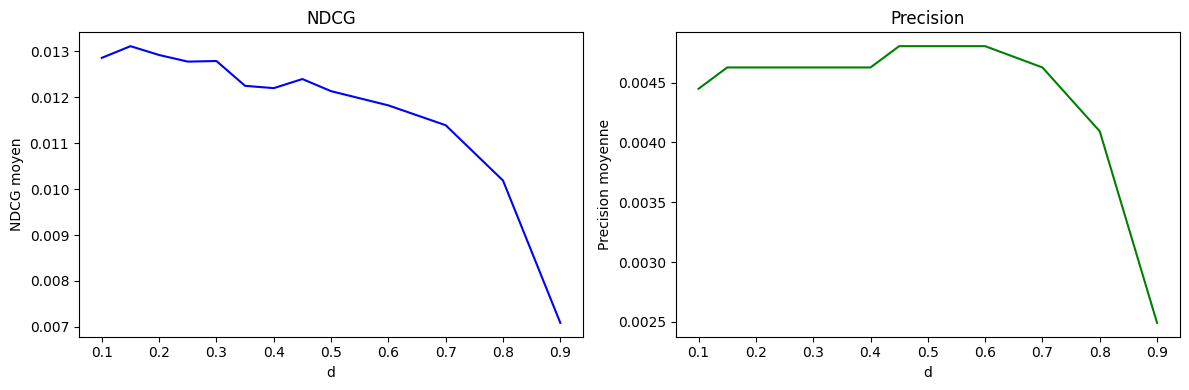

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(d_grid, ndcg_mean, color='b')
ax1.set_xlabel("d")
ax1.set_ylabel("NDCG moyen")
ax1.set_title("NDCG")

ax2.plot(d_grid, precision_mean, color='g')
ax2.set_xlabel("d")
ax2.set_ylabel("Precision moyenne")
ax2.set_title("Precision")

plt.tight_layout()
plt.show()

In [33]:
d = 0.45   # bon compromis entre précision et ndcg
max_iter = 100
tol = 1e-6

recom = {}
ndcg_scores = []
precision_scores = []

for (idx, id) in tqdm(ids_test.values):
    r = pagerank(adjacency,idx-1,d,max_iter,tol)
    known_refs = adjacency[idx-1].indices
    r[idx-1] = -1
    r[known_refs] = -1
    top_indices = r.argsort()[::-1]
    top20 = top_indices[:20]  #on récupère les top 20
    top20 = top20 + 1  #on récupère le vrai indice
    indices_recom = ids[ids['n'].isin(top20)]['id'].values

    #mise en forme
    recom[id] = " ".join(map(str, indices_recom))

print(f"\nNDCG ensemble de validation : {ndcg_mean[d_grid.index(d)]}")
print(f"Precision ensemble de validation : {precision_mean[d_grid.index(d)]}")

100%|██████████| 100/100 [00:12<00:00,  8.08it/s]


NDCG ensemble de validation : 0.012398668440969627
Precision ensemble de validation : 0.004804270462633453


In [15]:
#création du fichier résultats
df = pd.DataFrame(list(recom.items()), columns=['id', 'recommandations'])
df.to_csv("soumissionPR.csv", index=False)

In [34]:
print("Score NDCG kaggle : 0.16432")

Score NDCG kaggle : 0.16432


## 1.4 Discussion

Les résultats sur l'ensemble de validation ne sont vraiment pas très convaincants (peut être que l'ensemble est mal constitué). En revanche, le score Kagle est convenable en choisissant un d=0.45 intermédiaire. Il y a tout de même de la place pour de l'amélioration car cette approche reste un peu trop simpliste pour un problème de ce type. Nous pouvons également mieux tirer partie d'un aussi grand nombre d'exemples.

# 2. NGCF

## 2.1 Description

NGCF est conçu pour exploiter la structure de graphe (ici, le graphe de citations entre articles). Contrairement aux méthodes classiques comme la factorisation de matrices ou les modèles de filtrage collaboratif basés sur des interactions directes, NGCF propage les embeddings (représentations vectorielles) à travers le graphe. Dans notre implémentation on laisse la possibilité de donner une matrice d'embedding initial ou bien de partir d'une matrice initialisée aléatoirement, cela permet de mêler des approches contenu et collaborative dans un contexte de données qui ont une forme de graphe. Comme les embeddings feather donnés sont trop grand nous avons réduit leur dimension par PCA pour garder un maximum d'information et pouvoir tenir compte de la sémantique sans avoir des calculs trop longs. Le NGCF fonctionne à la base sur un paterne item-utilisateur, ici nous avons simplifié à item-item ce qui simplifie la matrice de propagation `L`.

En gardant en tête que nous testerons aussi un modèle lightGCN, nous avons adopté une approche orientée objet pour éviter les duplications de code.


## 2.2 Implémentation et Résultats

In [ ]:
# PCA pour avoir des embeddings initialisés à partir de la sémantique des articles
from sklearn.decomposition import PCA

print("Chargement des embeddings à partir du fichier feather")
feather_embed = pd.read_feather('data/embeddings.feather')
feather_embed.head()

feather_indexed = feather_embed.set_index('id')
embed_cols = [c for c in feather_embed.columns if c != 'id']

E0_rows = []
missing = 0
for _, row in ids.sort_values('n').iterrows():
    hex_id = row['id']
    if hex_id in feather_indexed.index:
        E0_rows.append(feather_indexed.loc[hex_id, embed_cols].values)
    else:
        E0_rows.append(np.zeros(len(embed_cols)))
        missing += 1

E0_feather = np.array(E0_rows, dtype=np.float32)
print(f"E0 shape : {E0_feather.shape}")           # (67294, 4096)



print("Compression PCA des embeddings")
pca = PCA(n_components=256)
E0_compressed256 = pca.fit_transform(E0_feather)
pca = PCA(n_components=128)
E0_compressed128 = pca.fit_transform(E0_feather)
pca = PCA(n_components=64)
E0_compressed64 = pca.fit_transform(E0_feather)

Chargement des embeddings à partir du fichier feather
E0 shape : (67294, 4096)
Compression PCA des embeddings


In [ ]:
# base GCN commune à NGCF et lightGCN
class GCN_Base(nn.Module):
    def __init__(self, adjacency, E0, n_layers=3, embed_size=64):
        super().__init__()
        self.n_layers = n_layers
        self.loss_history = []
        self.val_history = []
        n_items = adjacency.shape[0]

        # embeddings initiaux (pré-calculés)
        if E0 is not None:
            self.E0 = nn.Parameter(torch.tensor(E0, dtype=torch.float32))
        else:
            self.E0 = nn.Parameter(torch.empty(n_items, embed_size))
            nn.init.xavier_uniform_(self.E0)

        # symétrisation du graphe
        A = adjacency + adjacency.T
        A = A.tocsr()
        A.data = np.ones_like(A.data)
        A.eliminate_zeros()
        self.register_buffer('L', self.normalize(A))


    def normalize(self, A):
        degrees = np.array(A.sum(axis=1)).flatten()

        D_inv_sqrt = sp.diags(1.0 / np.sqrt(degrees + 1e-8))
        L = D_inv_sqrt @ A @ D_inv_sqrt

        L = L.tocoo()
        indices = torch.tensor(np.vstack((L.row, L.col)),dtype=torch.long)
        values = torch.tensor(L.data, dtype=torch.float32)
        return torch.sparse_coo_tensor(indices,values,L.shape).coalesce()



    def bpr_loss(self, E, i, j, k):
        e_i, e_j, e_k = E[i], E[j], E[k]

        pos = (e_i * e_j).sum(dim=1)
        neg = (e_i * e_k).sum(dim=1)

        return -torch.log(torch.sigmoid(pos - neg) + 1e-8).mean()


    def load_checkpoint(self, checkpoint_path, device):
        if os.path.exists(checkpoint_path):
            print(f"Checkpoint trouvé, reprise depuis {checkpoint_path}")
            checkpoint = torch.load(checkpoint_path, map_location=device)
            self.load_state_dict(checkpoint['model_state'])
            self.E0 = nn.Parameter(checkpoint['E0'])
            self.loss_history = checkpoint.get('loss_history', [])
            self.val_history = checkpoint.get('val_history', [])
            return checkpoint
        else:
            print("Aucun checkpoint trouvé, entraînement depuis le début.")
            return None

    def fit(
        self,
        adjacency_train,
        test_dict,
        n_epochs=50,
        batch_size=2048,
        lr=1e-3,
        lambda_reg=1e-4,
        device="cuda",
        checkpoint_path=None
    ):

        device = torch.device(device if torch.cuda.is_available() else "cpu")

        self.to(device)
        self.L = self.L.to(device)

        optimizer = Adam(self.parameters(), lr=lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)

        start_epoch = 0
        if os.path.exists(checkpoint_path):
            print(f"Checkpoint trouvé, reprise depuis {checkpoint_path}")
            checkpoint = torch.load(checkpoint_path, map_location=device)
            self.load_state_dict(checkpoint['model_state'])
            optimizer.load_state_dict(checkpoint['optimizer_state'])
            start_epoch = checkpoint.get('epoch', 0) + 1
            loss_history = checkpoint.get('loss_history', [])
            val_history = checkpoint.get('val_history', [])
            self.loss_history = loss_history
            self.val_history = val_history
            self.E0 = nn.Parameter(checkpoint['E0'])
            print(f"Reprise à l'epoch {start_epoch + 1}/{n_epochs}")


        rows, cols = adjacency_train.nonzero()

        n_pairs = len(rows)
        n_items = adjacency_train.shape[0]

        for epoch in range(start_epoch + 1, n_epochs):
            print(f"Epoch {epoch+1}/{n_epochs}")
            self.train()

            perm = np.random.permutation(n_pairs)
            rows_shuffled = rows[perm]
            cols_shuffled = cols[perm]

            total_loss = 0
            n_batches = 0
            for start in range(0, n_pairs, batch_size):
                print(f"\rBatch {start//batch_size + 1}/{(n_pairs + batch_size - 1) // batch_size}",end="", flush=True)
                i_batch = rows_shuffled[start:start+batch_size]
                j_batch = cols_shuffled[start:start+batch_size]
                k_batch = np.random.randint(0, n_items, size=len(i_batch)) # quasiment sur que k_batch ne contient pas de paires positives (i, k) car la matrice est très creuse, mais même si c'était le cas ça ne changerait rien à l'entrainement par loi des grands nombres.

                i_t = torch.tensor(i_batch, dtype=torch.long, device=device)
                j_t = torch.tensor(j_batch, dtype=torch.long, device=device)
                k_t = torch.tensor(k_batch, dtype=torch.long, device=device)

                optimizer.zero_grad()


                E = self.forward()
                loss_bpr = self.bpr_loss(E, i_t, j_t, k_t)
                reg = (self.E0[i_t].norm(2).pow(2) + self.E0[j_t].norm(2).pow(2) + self.E0[k_t].norm(2).pow(2)) / len(i_t)
                loss = loss_bpr + lambda_reg * reg

                loss.backward()      # Au lieu de scaler.scale(loss).backward()
                optimizer.step()

                del E

                total_loss += loss.item()
                n_batches += 1

            avg_loss = total_loss / n_batches
            self.loss_history.append(avg_loss)

            val_ndcg, val_precision = evaluate_val(self, test_dict, adjacency_train)
            self.val_history.append((val_ndcg,val_precision))
            scheduler.step(val_ndcg)
            print(f"\nEpoch {epoch+1} - Loss: {avg_loss:.4f} - Val : NDCG: {val_ndcg:.4f}, Prec:{val_precision:.4f}")

            if checkpoint_path is not None:

                torch.save(
                    {
                        "epoch": epoch,
                        "model_state": self.state_dict(),
                        "optimizer_state": optimizer.state_dict(),
                        "loss_history": self.loss_history,
                        "val_history": self.val_history,
                        "E0": self.E0.detach().cpu()
                    },
                    checkpoint_path
                )

        return self.val_history, self.loss_history

    def generate_submission_file(self,checkpoint_path, submission_path):
        if os.path.exists(checkpoint_path):
            self.load_checkpoint(checkpoint_path, device="cuda")

        test_ids = pd.read_csv('data/TP4-ids-test.csv', index_col=0)
        recommendations = generate_recommendations(model, test_ids, ids, adjacency)
        recommendations.to_csv(submission_path, index=False)
        print(recommendations.head())

    def plot_training_curves(self):
        if not self.loss_history or not self.val_history:
            print("Historique vide. Lancez d'abord l'entraînement (fit).")
            return

        epochs = range(1, len(self.loss_history) + 1)
        ndcg_scores, prec_scores = zip(*self.val_history)
        plt.figure(figsize=(15, 5))

        plt.subplot(1, 2, 1)
        plt.plot(epochs, self.loss_history, color='tab:red', label='BPR Loss', linewidth=2)
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Évolution de la Training Loss')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()


        plt.subplot(1, 2, 2)
        plt.plot(epochs, ndcg_scores, color='tab:blue', label='NDCG@20', marker='o', markersize=4)
        plt.plot(epochs, prec_scores, color='tab:green', label='Precision@5', marker='s', markersize=4)
        plt.xlabel('Epochs')
        plt.ylabel('Score (0-1)')
        plt.ylim(0, max(max(ndcg_scores), max(prec_scores)) * 1.2) # Ajuste l'échelle Y
        plt.title('Métriques de Validation')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()

        plt.tight_layout()
        plt.show()


In [ ]:
class NGCF_ItemItem(GCN_Base):
    def __init__(self, adjacency, E0, n_layers=3,embed_size=64):
        super().__init__(adjacency, E0, n_layers,embed_size)
        embed_size = self.E0.shape[1]

        self.W1 = nn.ModuleList([nn.Linear(embed_size, embed_size, bias=False) for _ in range(n_layers)])
        self.W2 = nn.ModuleList([nn.Linear(embed_size, embed_size, bias=False) for _ in range(n_layers)])
        # Si on normalise pas entre les couches les valeurs explosent et ça diverge donc on ajoute une normalisation après chaque couche
        self.norms = nn.ModuleList([nn.LayerNorm(embed_size) for _ in range(n_layers)])

    def forward(self):
        E = self.E0
        all_embeddings = [E]
        for l in range(self.n_layers):
            LE = torch.sparse.mm(self.L, E)
            LE = nn.functional.normalize(LE, p=2, dim=1)
            term1 = self.W1[l](LE + E)           # (L+I)E.W1
            term2 = self.W2[l](LE * E)            # L(E°E).W2
            E = nn.functional.leaky_relu(term1 + term2)
            E = self.norms[l](E)
            all_embeddings.append(E)

        E_final = torch.cat(all_embeddings, dim=1)
        return E_final

### **NGCF** -- **embedding inital PCA** -- dim **64**
mélange d'une approche contenu (sémantique contenu initalement dans le PCA) enrichi par le collaboratif

In [ ]:
model = NGCF_ItemItem(
    adjacency_train,
    E0=E0_compressed64,
    n_layers=2,
)

torch.cuda.empty_cache()
print(f"cuda available : {torch.cuda.is_available()}")

val_hist, loss_hist = model.fit(
    adjacency_train,
    val_indexes_hidden_refs,
    n_epochs=50,
    batch_size=2048,
    lr=1e-3,
    checkpoint_path="checkpoints/checkpoint_ngcf_2layer_feather64.pt"
)

cuda available : True
Checkpoint trouvé, reprise depuis checkpoints/checkpoint_ngcf_2layer_feather64.pt
Reprise à l'epoch 51/50


c:\Users\alex\Desktop\academique\cours polymtl\log6308\tp4_bis\Paper-recommender\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\alex\AppData\Local\Temp\ipykernel_3756\2815188904.py:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommen

Checkpoint trouvé, reprise depuis checkpoints/checkpoint_ngcf_2layer_feather64.pt
Checkpoint trouvé, reprise depuis checkpoints/checkpoint_ngcf_2layer_feather64.pt


C:\Users\alex\AppData\Local\Temp\ipykernel_3756\1547041874.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)

                         id                                    recommandations
0  56d87c8bdabfae2eee45fce6  53e9ab48b7602d97034dc28f 558b3daa84ae84d265c24...
1  53e9b7d9b7602d9704389448  557ee0d2d19faf961d16d246 558a309be4b0b32fcb355...
2  53e99e04b7602d97026ca90e  53e9a577b7602d9702ea2a1a 53e9bdfdb7602d9704ab1...
3  53e9b32bb7602d9703dfdacf  53e9a97bb7602d97032d37a4 53e9a472b7602d9702d8f...
4  53e9b9adb7602d970459ef8c  53e9acd3b7602d97036b29a9 53e9a480b7602d9702d9b...


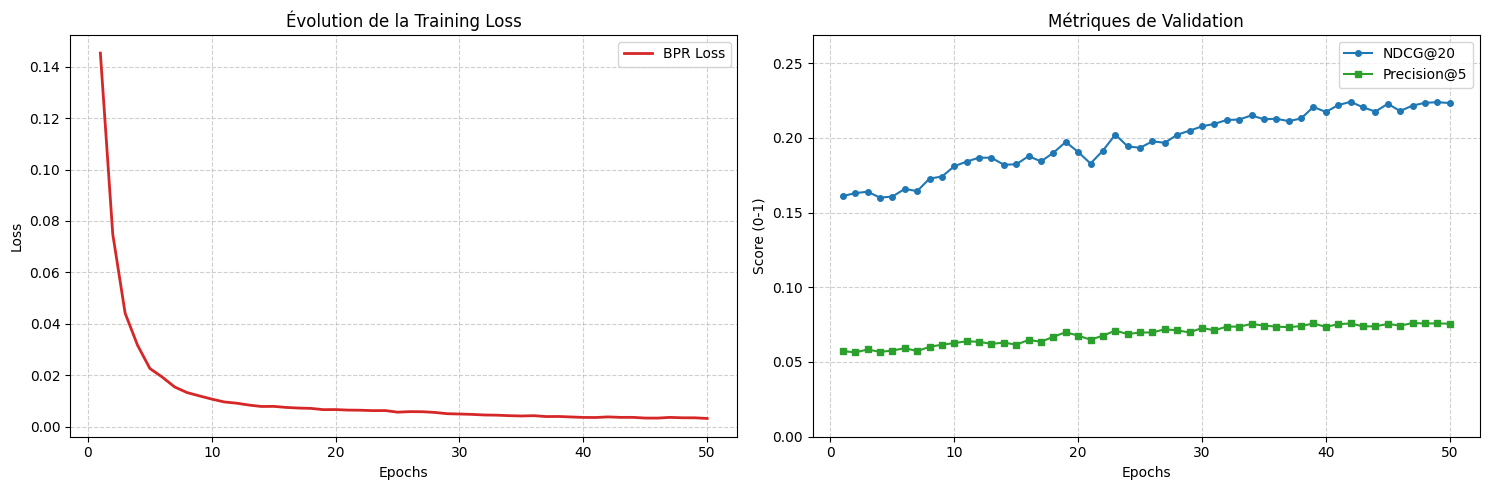

In [ ]:
model = NGCF_ItemItem(
    adjacency_train,
    E0=E0_compressed64,
    n_layers=2,
)

model.load_checkpoint("checkpoints/checkpoint_ngcf_2layer_feather64.pt", device="cuda")
model.generate_submission_file("checkpoints/checkpoint_ngcf_2layer_feather64.pt", "soumissions/submission_ngcf_2layer_feather64.csv")
model.plot_training_curves()

In [ ]:
print(f"Pour NGCF + PCA 64 : \n\n\t > Résultats kaggle : NDCG : {0.20955}")

Pour NGCF + PCA 64 : 

	 > Résultats kaggle : NDCG : 0.20955


### **NGCF** -- **aucun embedding inital** -- dim **64**
approche purement collaborative sur graphe

In [ ]:
model = NGCF_ItemItem(
        adjacency_train,
        E0=None,
        n_layers=2,
        embed_size=64
    )

torch.cuda.empty_cache()
print(f"cuda available : {torch.cuda.is_available()}")

val_hist, loss_hist = model.fit(
    adjacency_train,
    val_indexes_hidden_refs,
    n_epochs=70,
    batch_size=2048,
    lr=1e-3,
    checkpoint_path="checkpoints/checkpoint_ngcf_2layer_noInit64.pt"
)

Checkpoint trouvé, reprise depuis checkpoints/checkpoint_ngcf_2layer_noInit64.pt
Checkpoint trouvé, reprise depuis checkpoints/checkpoint_ngcf_2layer_noInit64.pt


C:\Users\alex\AppData\Local\Temp\ipykernel_3756\1952190676.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)

                         id                                    recommandations
0  56d87c8bdabfae2eee45fce6  53e9ab48b7602d97034dc28f 53e998bfb7602d97020f6...
1  53e9b7d9b7602d9704389448  53e99ab2b7602d970232bf0b 558a9da7e4b0b32fcb37d...
2  53e99e04b7602d97026ca90e  5583c6db0cf2b21478edda78 53e9b91eb7602d9704507...
3  53e9b32bb7602d9703dfdacf  53e9a97bb7602d97032d37a4 53e99db1b7602d970266d...
4  53e9b9adb7602d970459ef8c  53e9acd3b7602d97036b29a9 53e9983db7602d9702065...


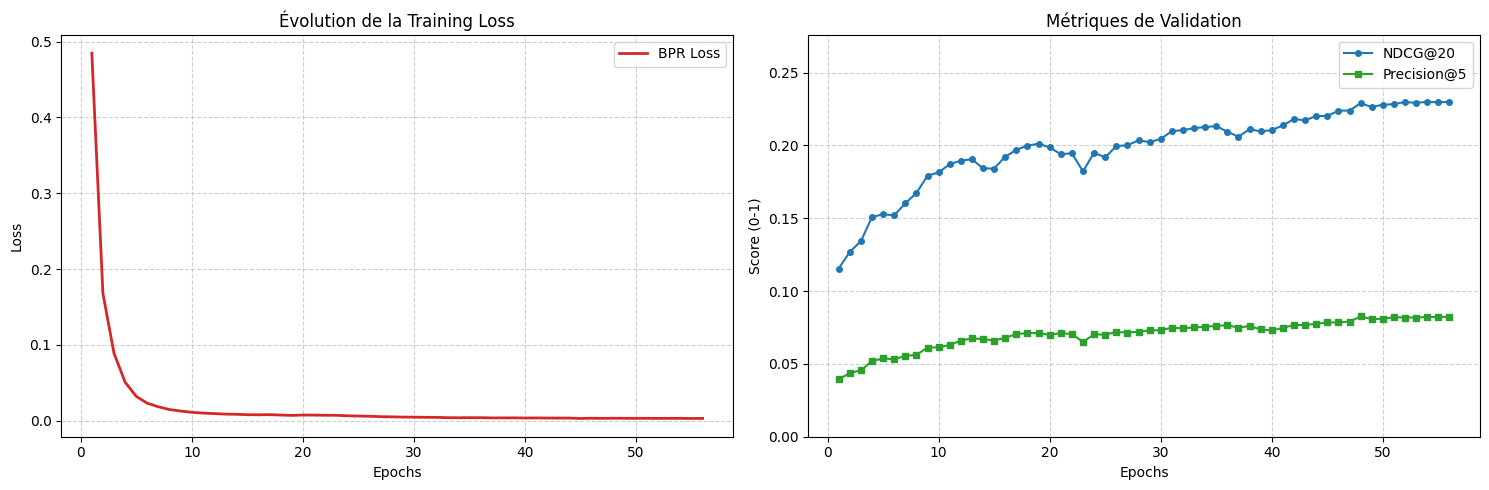

In [ ]:
model = NGCF_ItemItem(
    adjacency_train,
    E0=None,
    n_layers=2,
)

model.load_checkpoint("checkpoints/checkpoint_ngcf_2layer_noInit64.pt", device="cuda")
model.generate_submission_file("checkpoints/checkpoint_ngcf_2layer_noInit64.pt", "soumissions/submission_ngcf_2layer_noInit64.csv")
model.plot_training_curves()

In [ ]:
print(f"Pour NGCF sans initialisation & dim 64 : \n\n\t > Résultats kaggle : NDCG : {0.25025}")

Pour NGCF sans initialisation & dim 64 : 

	 > Résultats kaggle : NDCG : 0.25025


**Modèles plus larges (embedding de dim 128):**

### **NGCF** -- **embedding inital PCA** -- dim **128**

In [ ]:
model = NGCF_ItemItem(
        adjacency_train,
        E0=E0_compressed128,
        n_layers=2,
    )

torch.cuda.empty_cache()
print(f"cuda available : {torch.cuda.is_available()}")

val_hist, loss_hist = model.fit(
    adjacency_train,
    val_indexes_hidden_refs,
    n_epochs=50,
    batch_size=2048,
    lr=1e-3,
    checkpoint_path="checkpoints/checkpoint_ngcf_2layer_feather128.pt"
)

cuda available : True
Checkpoint trouvé, reprise depuis checkpoints/checkpoint_ngcf_2layer_feather128.pt
Reprise à l'epoch 16/50
Epoch 17/50
Batch 1/303

c:\Users\alex\Desktop\academique\cours polymtl\log6308\tp4_bis\Paper-recommender\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\alex\AppData\Local\Temp\ipykernel_3756\1952190676.py:83: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommen

Batch 303/303
Epoch 17 - Loss: 0.0097 - Val : NDCG: 0.1821, Prec:0.0658
Epoch 18/50
Batch 303/303
Epoch 18 - Loss: 0.0093 - Val : NDCG: 0.1837, Prec:0.0664
Epoch 19/50
Batch 303/303
Epoch 19 - Loss: 0.0086 - Val : NDCG: 0.1867, Prec:0.0689
Epoch 20/50
Batch 303/303
Epoch 20 - Loss: 0.0078 - Val : NDCG: 0.1899, Prec:0.0699
Epoch 21/50
Batch 303/303
Epoch 21 - Loss: 0.0076 - Val : NDCG: 0.1915, Prec:0.0705
Epoch 22/50
Batch 303/303
Epoch 22 - Loss: 0.0075 - Val : NDCG: 0.1912, Prec:0.0708
Epoch 23/50
Batch 303/303
Epoch 23 - Loss: 0.0075 - Val : NDCG: 0.1927, Prec:0.0705
Epoch 24/50
Batch 303/303
Epoch 24 - Loss: 0.0065 - Val : NDCG: 0.1972, Prec:0.0722
Epoch 25/50
Batch 303/303
Epoch 25 - Loss: 0.0067 - Val : NDCG: 0.2050, Prec:0.0770
Epoch 26/50
Batch 303/303
Epoch 26 - Loss: 0.0063 - Val : NDCG: 0.2032, Prec:0.0747
Epoch 27/50
Batch 303/303
Epoch 27 - Loss: 0.0060 - Val : NDCG: 0.2064, Prec:0.0767
Epoch 28/50
Batch 303/303
Epoch 28 - Loss: 0.0059 - Val : NDCG: 0.2080, Prec:0.0762
Epoc

Checkpoint trouvé, reprise depuis checkpoints/checkpoint_ngcf_2layer_feather128.pt
Checkpoint trouvé, reprise depuis checkpoints/checkpoint_ngcf_2layer_feather128.pt


C:\Users\alex\AppData\Local\Temp\ipykernel_3756\1952190676.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)

                         id                                    recommandations
0  56d87c8bdabfae2eee45fce6  53e9ab48b7602d97034dc28f 53e998bfb7602d97020f6...
1  53e9b7d9b7602d9704389448  557ee0d2d19faf961d16d246 53e99ab2b7602d970232b...
2  53e99e04b7602d97026ca90e  558c197d84ae6766fdf10bcc 53e998bfb7602d97020f6...
3  53e9b32bb7602d9703dfdacf  53e9b268b7602d9703d0d3dd 53e9a210b7602d9702b15...
4  53e9b9adb7602d970459ef8c  53e9b8c0b7602d970449cd6a 53e9bde9b7602d9704a98...


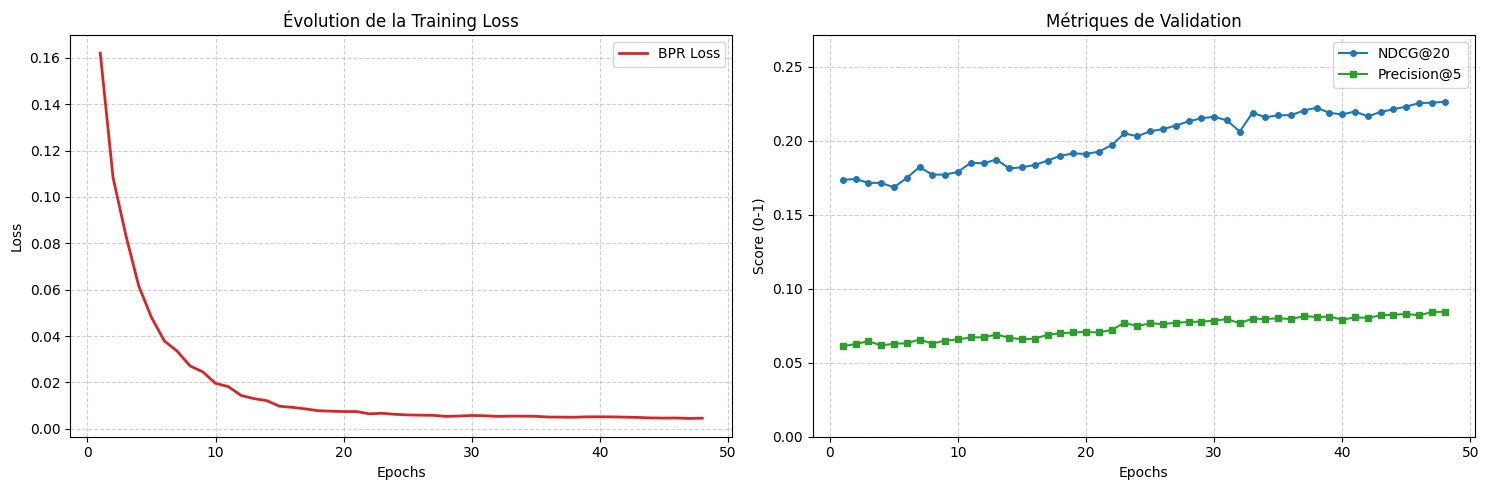

In [ ]:
model = NGCF_ItemItem(
    adjacency_train,
    E0=E0_compressed128,
    n_layers=2,
)

model.load_checkpoint("checkpoints/checkpoint_ngcf_2layer_feather128.pt", device="cuda")
model.generate_submission_file("checkpoints/checkpoint_ngcf_2layer_feather128.pt", "soumissions/submission_ngcf_2layer_feather128.csv")
model.plot_training_curves()

In [ ]:
print(f"Pour NGCF + PCA 128 : \n\n\t > Résultats kaggle : NDCG : {0.19469}")

Pour NGCF + PCA 128 : 

	 > Résultats kaggle : NDCG : 0.19469


### **NGCF** -- **aucun embedding inital** -- dim **128**

In [ ]:
model = NGCF_ItemItem(
        adjacency_train,
        E0=None,
        n_layers=2,
        embed_size=128
    )

torch.cuda.empty_cache()
print(f"cuda available : {torch.cuda.is_available()}")

val_hist, loss_hist = model.fit(
    adjacency_train,
    val_indexes_hidden_refs,
    n_epochs=50,
    batch_size=2048,
    lr=1e-3,
    checkpoint_path="checkpoints/checkpoint_ngcf_2layer_noInit128.pt"
)

Checkpoint trouvé, reprise depuis checkpoints/checkpoint_ngcf_2layer_noInit128.pt
Checkpoint trouvé, reprise depuis checkpoints/checkpoint_ngcf_2layer_noInit128.pt


C:\Users\alex\AppData\Local\Temp\ipykernel_3756\1952190676.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)

                         id                                    recommandations
0  56d87c8bdabfae2eee45fce6  53e9ab48b7602d97034dc28f 53e998bfb7602d97020f6...
1  53e9b7d9b7602d9704389448  53e9a97ab7602d97032d279c 53e9bb5ab7602d9704798...
2  53e99e04b7602d97026ca90e  558c90b2e4b0cfb70a1e66a0 53e99f70b7602d9702847...
3  53e9b32bb7602d9703dfdacf  53e9a87eb7602d97031cc025 53e9a50fb7602d9702e34...
4  53e9b9adb7602d970459ef8c  53e9bde9b7602d9704a98584 53e99a67b7602d97022d3...


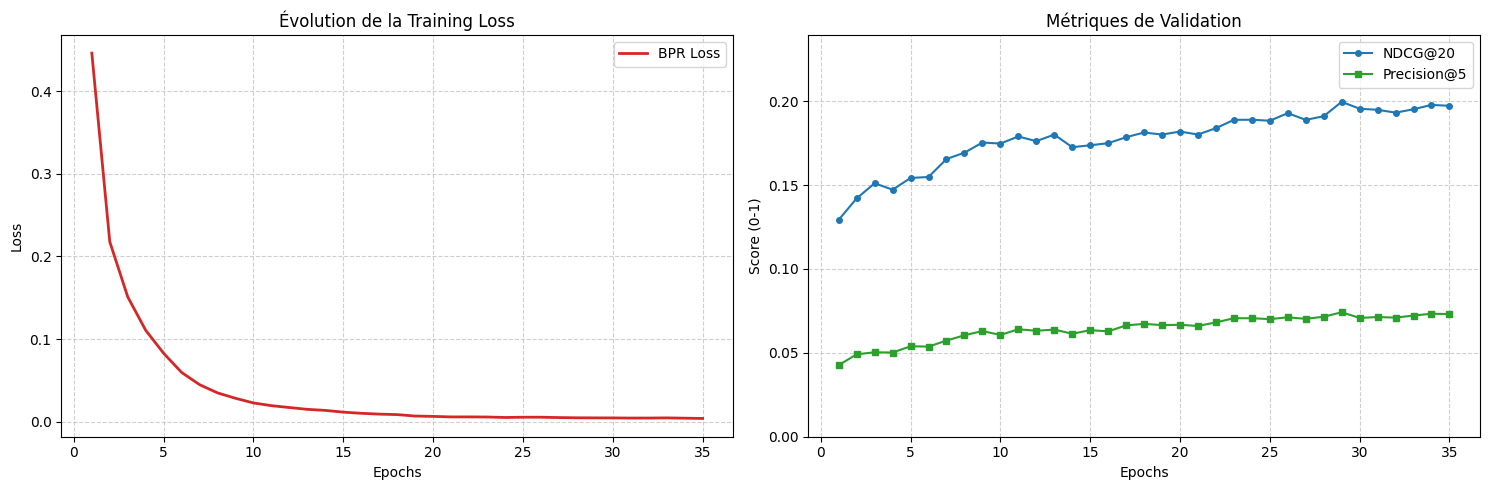

In [ ]:
model = NGCF_ItemItem(
    adjacency_train,
    E0=None,
    n_layers=2,
    embed_size=128
)

model.load_checkpoint("checkpoints/checkpoint_ngcf_2layer_noInit128.pt", device="cuda")
model.generate_submission_file("checkpoints/checkpoint_ngcf_2layer_noInit128.pt", "soumissions/submission_ngcf_2layer_noInit128.csv")
model.plot_training_curves()

In [ ]:
print(f"Pour NGCF sans initialisation & dim 128 : \n\n\t > Résultats kaggle : NDCG : {0.17632}")

Pour NGCF sans initialisation & dim 128 : 

	 > Résultats kaggle : NDCG : 0.17632


## 2.3 Discussion

Comme on le voit, nous avons effectué beaucoup d'expérimentation en faisant varier les paramètres (on a fait une sorte de grid search à la main pour limiter le plus possible les calculs redondants et en limitant les époques lorsque faire un entrainement trop long serait une perte de temps) nous n'avons pas pu faire varier les paramètres de nombre de layer de propagation (on l'a laissé à 2) car cela multipliait trop l'espace de recherche des hyperparamètres et cela aurait été beaucoup trop chronophage pour nous. Nous avons donc fait varier l'embedding d'input : soit sans aucun embedding d'input soit avec un embedding de contenu et les dimmensions des embeddings 64 ou 128.

Ce qu'on constate globalement :
- Lorsqu'on utilise un embedding d'input (basé sur le contenu) : on part d'une précision plus haute au première époque : cela s'explique par le fait que les embeddings contiennent déjà beaucoup d'information
- Sans aucun embedding : la précision est vraiment basse au première époque mais après plusieurs époques le retard est rattrapé, les embeddings initiaux ne semblent donc pas apporter de meilleur performance par rapport aux approches purement collaboratives.

Les meilleurs perf sur kaggle et sur notre set de validation sont obtenues avec le modèle en dimension 64 et sans embeddings initiaux, cependant ces 0.05 points de différence au NDCG par rapport aux autres modèles semblent être peu significatifs et plutôt du bruit car nos courbes de validations sont sensiblement similaires.

Il est important de noter que nous n'avons pas fait le même nombre d'époques sur tous les modèles pour des contraintes de temps de calcul très long, ces résultats sont donc à prendre avec des pincettes car certains modèles n'avaient sans doute pas tout à fait convergé.

# 3. LightGCN


## 3.1 Description

LightGCN fonctionne quasiment comme le NGCF à l'exception que le forward est largement simplifié sans avoir besoin de régulariser ni de faire d'opération autre que la propagation des embeddings voisins. L'implémentation est très simple grâce aux efforts faits pour unifier les implémentations de NGCF et lightGCN grâce à la programmation orientée objet.

## 3.2 Implémentation et Résultats

In [ ]:
# Pareil que NGCF mais sans les termes d'interaction explicites (LE * E) avec poids
class LightGCN_ItemItem(GCN_Base):

    def __init__(self, adjacency, E0, n_layers=3, embed_size=64):
        super().__init__(adjacency, E0, n_layers, embed_size)

    def forward(self):
        E = self.E0
        all_embeddings = [E]
        for _ in range(self.n_layers):
            E = torch.sparse.mm(self.L, E)
            all_embeddings.append(E)

        E_final = torch.stack(all_embeddings).mean(dim=0)
        return E_final

### **LightGCN** -- **embedding inital PCA** -- dim **64**
mélange d'une approche contenu (sémantique contenu initalement dans le PCA) enrichi par le collaboratif

In [ ]:
model = LightGCN_ItemItem(
    adjacency_train,
    E0=E0_compressed64,
    n_layers=2,
)

torch.cuda.empty_cache()
print(f"cuda available : {torch.cuda.is_available()}")

val_hist, loss_hist = model.fit(
    adjacency_train,
    val_indexes_hidden_refs,
    n_epochs=80,
    batch_size=2048,
    lr=1e-3,
    checkpoint_path="checkpoints/checkpoint_lgcn_2layer_feather64.pt"
)

cuda available : True
Checkpoint trouvé, reprise depuis checkpoints/checkpoint_lgcn_2layer_feather64.pt
Reprise à l'epoch 51/80
Epoch 52/80
Batch 1/303

C:\Users\alex\AppData\Local\Temp\ipykernel_3756\1952190676.py:83: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)

Batch 303/303
Epoch 52 - Loss: 0.0124 - Val : NDCG: 0.2182, Prec:0.0769
Epoch 53/80
Batch 303/303
Epoch 53 - Loss: 0.0125 - Val : NDCG: 0.2182, Prec:0.0769
Epoch 54/80
Batch 303/303
Epoch 54 - Loss: 0.0126 - Val : NDCG: 0.2182, Prec:0.0769
Epoch 55/80
Batch 303/303
Epoch 55 - Loss: 0.0124 - Val : NDCG: 0.2182, Prec:0.0769
Epoch 56/80
Batch 303/303
Epoch 56 - Loss: 0.0126 - Val : NDCG: 0.2182, Prec:0.0769
Epoch 57/80
Batch 303/303
Epoch 57 - Loss: 0.0126 - Val : NDCG: 0.2182, Prec:0.0769
Epoch 58/80
Batch 303/303
Epoch 58 - Loss: 0.0127 - Val : NDCG: 0.2182, Prec:0.0769
Epoch 59/80
Batch 303/303
Epoch 59 - Loss: 0.0125 - Val : NDCG: 0.2182, Prec:0.0769
Epoch 60/80
Batch 303/303
Epoch 60 - Loss: 0.0124 - Val : NDCG: 0.2182, Prec:0.0769
Epoch 61/80
Batch 303/303
Epoch 61 - Loss: 0.0124 - Val : NDCG: 0.2182, Prec:0.0769
Epoch 62/80
Batch 303/303
Epoch 62 - Loss: 0.0126 - Val : NDCG: 0.2182, Prec:0.0769
Epoch 63/80
Batch 303/303
Epoch 63 - Loss: 0.0126 - Val : NDCG: 0.2182, Prec:0.0769
Epoc

Checkpoint trouvé, reprise depuis checkpoints/checkpoint_lgcn_2layer_feather64.pt
Checkpoint trouvé, reprise depuis checkpoints/checkpoint_lgcn_2layer_feather64.pt


C:\Users\alex\AppData\Local\Temp\ipykernel_3756\1952190676.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)

                         id                                    recommandations
0  56d87c8bdabfae2eee45fce6  53e9ab48b7602d97034dc28f 53e9b91eb7602d9704507...
1  53e9b7d9b7602d9704389448  53e99ab2b7602d970232bf0b 53e9bb5ab7602d9704798...
2  53e99e04b7602d97026ca90e  5583c6db0cf2b21478edda78 53e9b91eb7602d9704507...
3  53e9b32bb7602d9703dfdacf  53e99885b7602d97020c04a5 53e9a210b7602d9702b15...
4  53e9b9adb7602d970459ef8c  53e9acd3b7602d97036b29a9 53e99885b7602d97020c0...


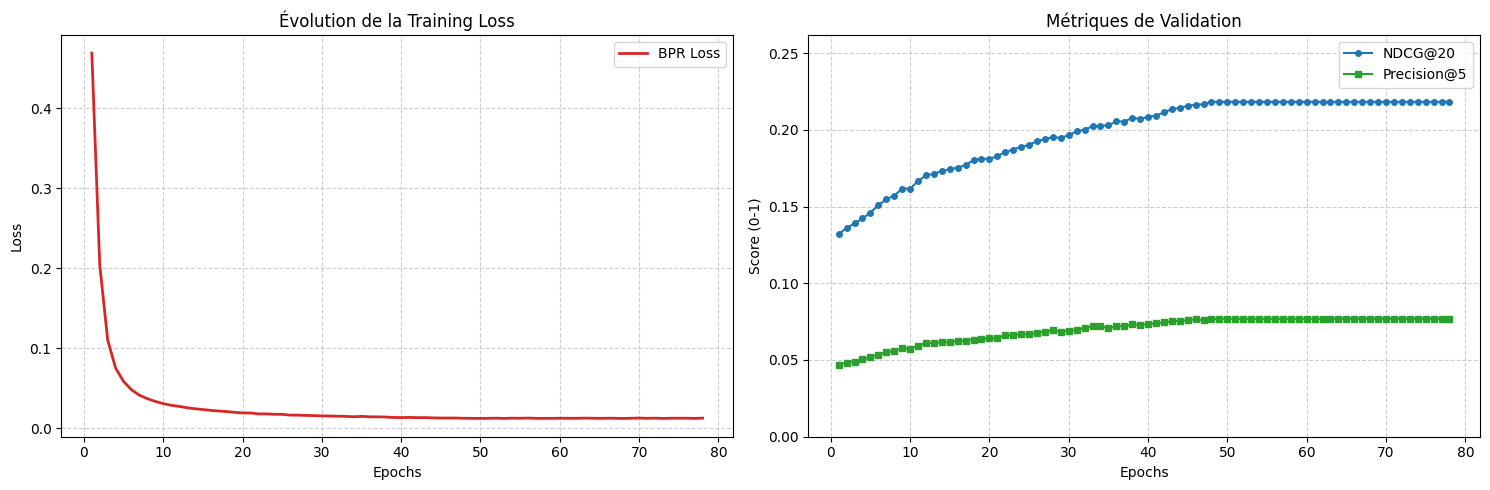

In [ ]:
model = LightGCN_ItemItem(
    adjacency_train,
    E0=E0_compressed64,
    n_layers=2,
)
model.load_checkpoint("checkpoints/checkpoint_lgcn_2layer_feather64.pt", device="cuda")
model.generate_submission_file("checkpoints/checkpoint_lgcn_2layer_feather64.pt", "soumissions/submission_lgcn_2layer_feather64.csv")
model.plot_training_curves()

In [ ]:
print(f"Pour LightGCN + PCA 64 : \n\n\t > Résultats kaggle : NDCG : {0.20342}")

Pour LightGCN + PCA 64 : 

	 > Résultats kaggle : NDCG : 0.20342


### **LightGCN** -- **aucun embedding inital** -- dim **64**
approche purement collaborative sur graphe

In [ ]:
model = LightGCN_ItemItem(
    adjacency_train,
    E0=None,
    n_layers=2,
)

torch.cuda.empty_cache()
print(f"cuda available : {torch.cuda.is_available()}")

val_hist, loss_hist = model.fit(
    adjacency_train,
    val_indexes_hidden_refs,
    n_epochs=80,
    batch_size=2048,
    lr=1e-3,
    checkpoint_path="checkpoints/checkpoint_lgcn_2layer_noInit64.pt"
)

Checkpoint trouvé, reprise depuis checkpoints/checkpoint_lgcn_2layer_noInit64.pt
Checkpoint trouvé, reprise depuis checkpoints/checkpoint_lgcn_2layer_noInit64.pt


C:\Users\alex\AppData\Local\Temp\ipykernel_3756\1952190676.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)

                         id                                    recommandations
0  56d87c8bdabfae2eee45fce6  53e9a04ab7602d9702932694 53e9ab48b7602d97034dc...
1  53e9b7d9b7602d9704389448  53e99ab2b7602d970232bf0b 53e9bb5ab7602d9704798...
2  53e99e04b7602d97026ca90e  5583c6db0cf2b21478edda78 53e9a04ab7602d9702932...
3  53e9b32bb7602d9703dfdacf  53e99885b7602d97020c04a5 53e9a210b7602d9702b15...
4  53e9b9adb7602d970459ef8c  53e99885b7602d97020c04a5 53e9acd3b7602d97036b2...


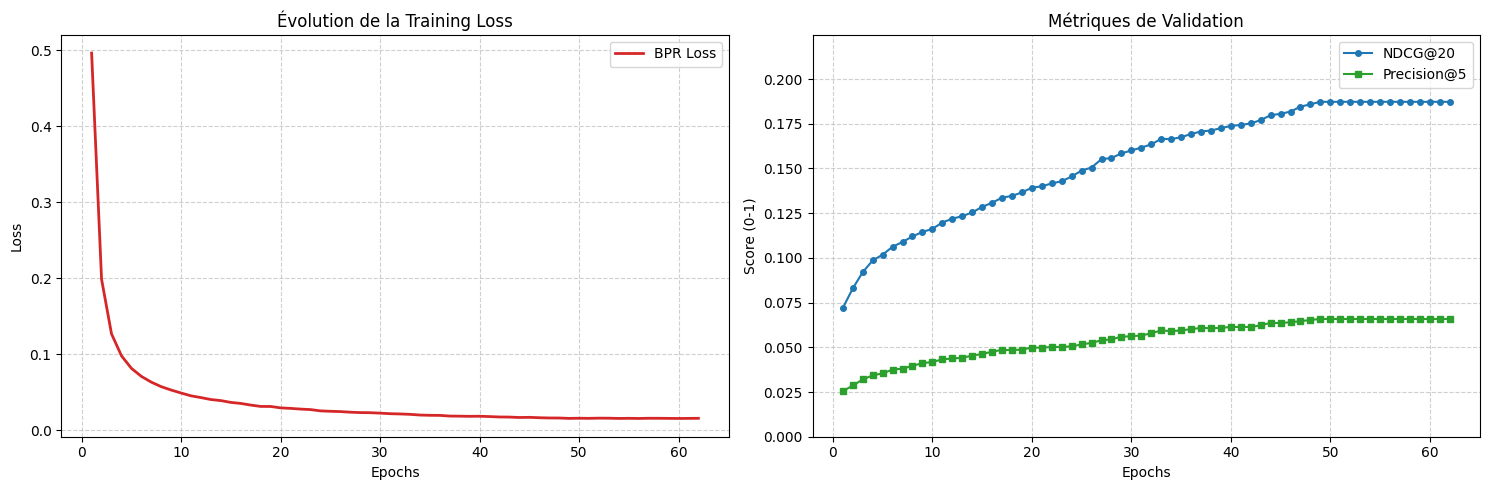

In [ ]:
model = LightGCN_ItemItem(
    adjacency_train,
    E0=None,
    n_layers=2,
)
model.load_checkpoint("checkpoints/checkpoint_lgcn_2layer_noInit64.pt", device="cuda")
model.generate_submission_file("checkpoints/checkpoint_lgcn_2layer_noInit64.pt", "soumissions/submission_lgcn_2layer_noInit64.csv")
model.plot_training_curves()

In [ ]:
print(f"Pour LightGCN sans initialisation & dim 64 : \n\n\t > Résultats kaggle : NDCG : {0.16923}")

Pour LightGCN sans initialisation & dim 64 : 

	 > Résultats kaggle : NDCG : 0.16923


**Modèles plus larges (embedding de dim 128):**

### **LightGCN** -- **embedding inital PCA** -- dim **128**

In [ ]:
model = LightGCN_ItemItem(
    adjacency_train,
    E0=E0_compressed128,
    n_layers=2,
)

torch.cuda.empty_cache()
print(f"cuda available : {torch.cuda.is_available()}")

val_hist, loss_hist = model.fit(
    adjacency_train,
    val_indexes_hidden_refs,
    n_epochs=80,
    batch_size=2048,
    lr=1e-3,
    checkpoint_path="checkpoints/checkpoint_lgcn_2layer_feather128.pt"
)

Checkpoint trouvé, reprise depuis checkpoints/checkpoint_lgcn_2layer_feather128.pt
Checkpoint trouvé, reprise depuis checkpoints/checkpoint_lgcn_2layer_feather128.pt


C:\Users\alex\AppData\Local\Temp\ipykernel_3756\1952190676.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)

                         id                                    recommandations
0  56d87c8bdabfae2eee45fce6  53e9a04ab7602d9702932694 53e9ab48b7602d97034dc...
1  53e9b7d9b7602d9704389448  53e99ab2b7602d970232bf0b 53e9bb5ab7602d9704798...
2  53e99e04b7602d97026ca90e  5583c6db0cf2b21478edda78 53e9a04ab7602d9702932...
3  53e9b32bb7602d9703dfdacf  53e99885b7602d97020c04a5 53e9a210b7602d9702b15...
4  53e9b9adb7602d970459ef8c  53e99885b7602d97020c04a5 53e9acd3b7602d97036b2...


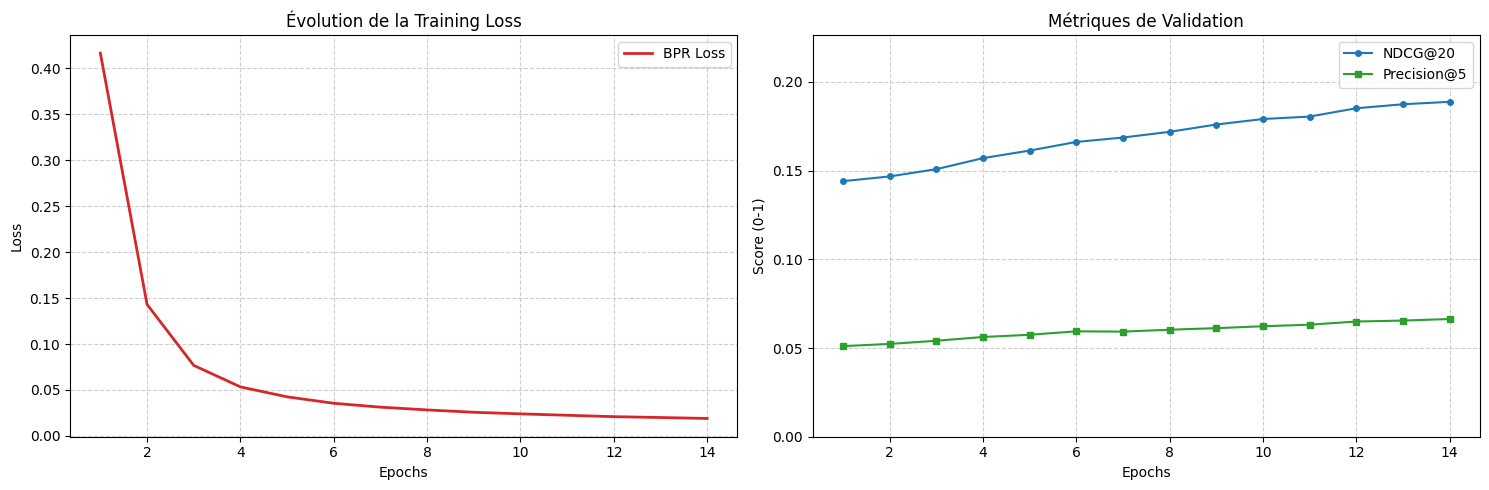

In [ ]:
model = LightGCN_ItemItem(
    adjacency_train,
    E0=E0_compressed128,
    n_layers=2,
)
model.load_checkpoint("checkpoints/checkpoint_lgcn_2layer_feather128.pt", device="cuda")
model.generate_submission_file("checkpoints/checkpoint_lgcn_2layer_feather128.pt", "soumissions/submission_lgcn_2layer_feather128.csv")
model.plot_training_curves()

In [ ]:
print(f"Pour LGCN + PCA 128 : \n\n\t > Résultats kaggle : NDCG : {0.17229}\n\n\t > Stoppé prématurément car la courbe ne présageait pas une amélioration significative")

Pour LGCN + PCA 128 : 

	 > Résultats kaggle : NDCG : 0.17229

	 > Stoppé prématurément car la courbe ne présageait pas une amélioration significative


In [ ]:
model = LightGCN_ItemItem(
    adjacency_train,
    E0=None,
    n_layers=2,
    embed_size=128
)

torch.cuda.empty_cache()
print(f"cuda available : {torch.cuda.is_available()}")

val_hist, loss_hist = model.fit(
    adjacency_train,
    val_indexes_hidden_refs,
    n_epochs=100,
    batch_size=2048,
    lr=1e-3,
    checkpoint_path="checkpoints/checkpoint_lgcn_2layer_noInit128.pt"
)

cuda available : True
Checkpoint trouvé, reprise depuis checkpoints/checkpoint_lgcn_2layer_noInit128.pt


C:\Users\alex\AppData\Local\Temp\ipykernel_18100\1952190676.py:83: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device

Reprise à l'epoch 81/100
Epoch 82/100
Batch 303/303
Epoch 82 - Loss: 0.0108 - Val : NDCG: 0.2522, Prec:0.0870
Epoch 83/100
Batch 303/303
Epoch 83 - Loss: 0.0106 - Val : NDCG: 0.2522, Prec:0.0870
Epoch 84/100
Batch 303/303
Epoch 84 - Loss: 0.0106 - Val : NDCG: 0.2522, Prec:0.0870
Epoch 85/100
Batch 303/303
Epoch 85 - Loss: 0.0105 - Val : NDCG: 0.2522, Prec:0.0870
Epoch 86/100
Batch 303/303
Epoch 86 - Loss: 0.0107 - Val : NDCG: 0.2522, Prec:0.0870
Epoch 87/100
Batch 303/303
Epoch 87 - Loss: 0.0106 - Val : NDCG: 0.2522, Prec:0.0870
Epoch 88/100
Batch 303/303
Epoch 88 - Loss: 0.0108 - Val : NDCG: 0.2522, Prec:0.0870
Epoch 89/100
Batch 303/303
Epoch 89 - Loss: 0.0107 - Val : NDCG: 0.2522, Prec:0.0870
Epoch 90/100
Batch 303/303
Epoch 90 - Loss: 0.0105 - Val : NDCG: 0.2522, Prec:0.0870
Epoch 91/100
Batch 303/303
Epoch 91 - Loss: 0.0104 - Val : NDCG: 0.2522, Prec:0.0870
Epoch 92/100
Batch 303/303
Epoch 92 - Loss: 0.0107 - Val : NDCG: 0.2522, Prec:0.0870
Epoch 93/100
Batch 303/303
Epoch 93 - Lo

Checkpoint trouvé, reprise depuis checkpoints/checkpoint_lgcn_2layer_noInit128.pt
Checkpoint trouvé, reprise depuis checkpoints/checkpoint_lgcn_2layer_noInit128.pt


C:\Users\alex\AppData\Local\Temp\ipykernel_18100\1952190676.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device

                         id                                    recommandations
0  56d87c8bdabfae2eee45fce6  53e9ab48b7602d97034dc28f 53e9a04ab7602d9702932...
1  53e9b7d9b7602d9704389448  53e99ab2b7602d970232bf0b 53e9bb5ab7602d9704798...
2  53e99e04b7602d97026ca90e  53e9a04ab7602d9702932694 5583c6db0cf2b21478edd...
3  53e9b32bb7602d9703dfdacf  53e99885b7602d97020c04a5 53e9bb80b7602d97047c6...
4  53e9b9adb7602d970459ef8c  53e99885b7602d97020c04a5 53e9acd3b7602d97036b2...


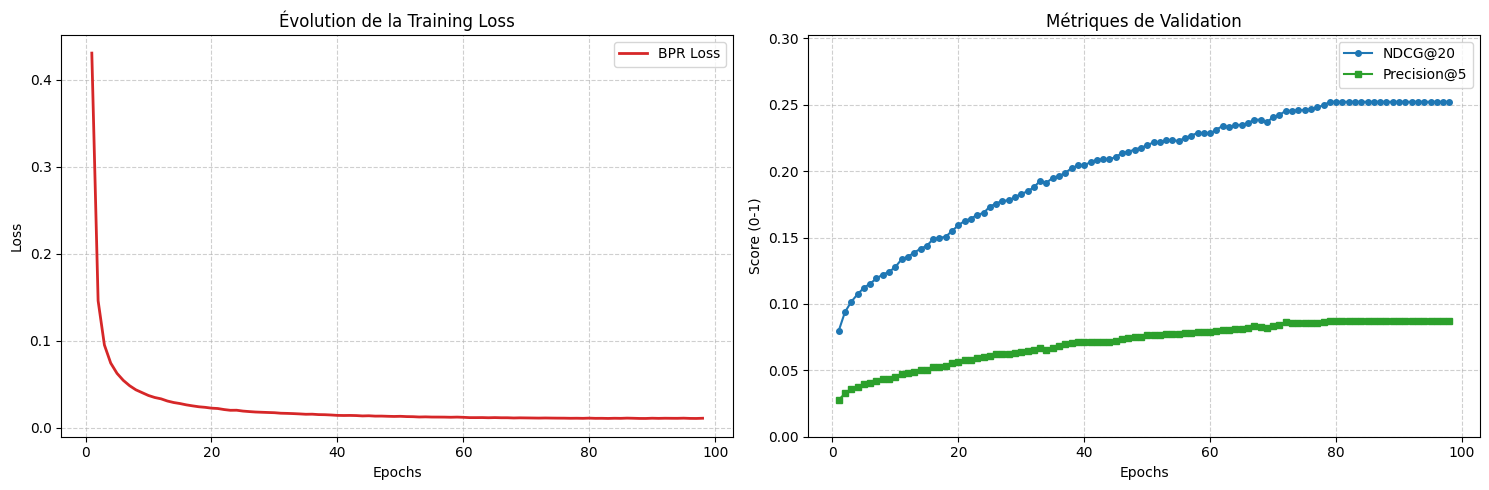

In [ ]:
model = LightGCN_ItemItem(
    adjacency_train,
    E0=None,
    n_layers=2,
    embed_size=128
)

model.load_checkpoint("checkpoints/checkpoint_lgcn_2layer_noInit128.pt", device="cuda")
model.generate_submission_file("checkpoints/checkpoint_lgcn_2layer_noInit128.pt", "soumissions/submission_lgcn_2layer_noInit128.csv")
model.plot_training_curves()

In [ ]:
print(f"Pour LightGCN sans initialisation & dim 128 : \n\n\t > Résultats kaggle : NDCG : {0.21837}\n\t > les courbe de validation partaient bien donc j'ai laissé tourner plus longtemps que prévu pour voir jusqu'où ça pouvait aller")

Pour LightGCN sans initialisation & dim 128 : 

	 > Résultats kaggle : NDCG : 0.21837
	 > les courbe de validation partaient bien donc j'ai laissé tourner plus longtemps que prévu pour voir jusqu'où ça pouvait aller


**Modèles plus larges (embedding de dim 256):**

### **LightGCN** -- **embedding inital PCA** -- dim **256**

In [ ]:
model = LightGCN_ItemItem(
    adjacency_train,
    E0=E0_compressed256,
    n_layers=2,
)

torch.cuda.empty_cache()
print(f"cuda available : {torch.cuda.is_available()}")

val_hist, loss_hist = model.fit(
    adjacency_train,
    val_indexes_hidden_refs,
    n_epochs=80,
    batch_size=2048,
    lr=1e-3,
    checkpoint_path="checkpoints/checkpoint_lgcn_2layer_feather256.pt"
)

Checkpoint trouvé, reprise depuis checkpoints/checkpoint_lgcn_2layer_feather256.pt


C:\Users\alex\AppData\Local\Temp\ipykernel_18100\1952190676.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device

Checkpoint trouvé, reprise depuis checkpoints/checkpoint_lgcn_2layer_feather256.pt
                         id                                    recommandations
0  56d87c8bdabfae2eee45fce6  53e9ab48b7602d97034dc28f 53e9a04ab7602d9702932...
1  53e9b7d9b7602d9704389448  53e99ab2b7602d970232bf0b 53e9bb5ab7602d9704798...
2  53e99e04b7602d97026ca90e  5583c6db0cf2b21478edda78 53e9b91eb7602d9704507...
3  53e9b32bb7602d9703dfdacf  53e99885b7602d97020c04a5 53e9a210b7602d9702b15...
4  53e9b9adb7602d970459ef8c  53e99885b7602d97020c04a5 53e9acd3b7602d97036b2...


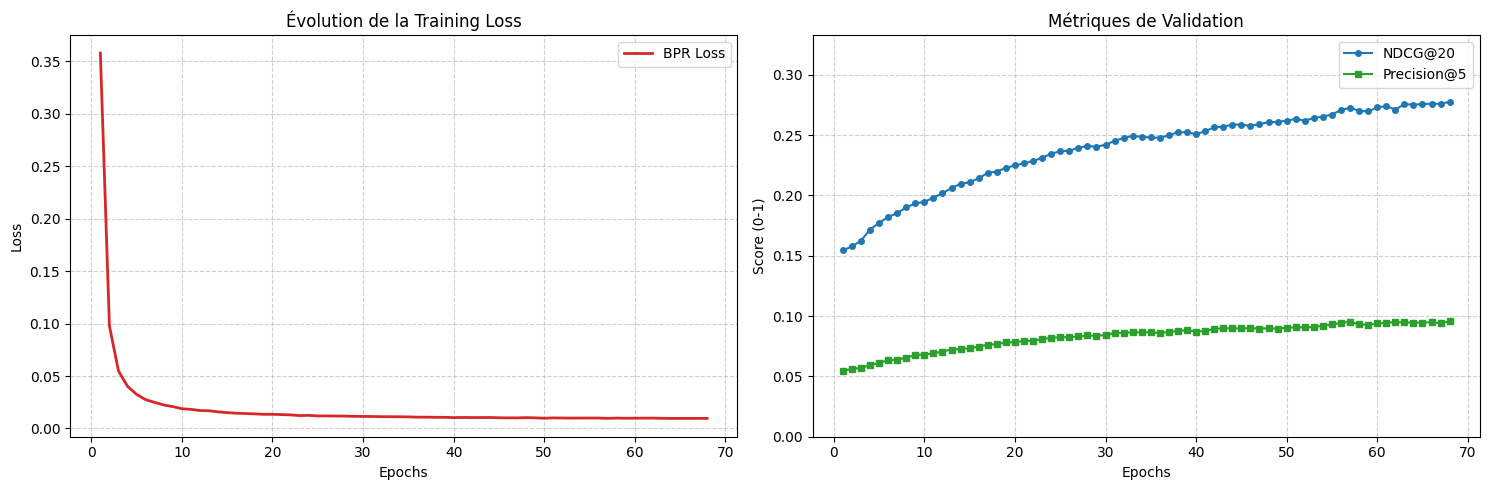

In [ ]:
model = LightGCN_ItemItem(
    adjacency_train,
    E0=E0_compressed256,
    n_layers=2,
)

model.load_checkpoint("checkpoints/checkpoint_lgcn_2layer_feather256.pt", device="cuda")
model.generate_submission_file("checkpoints/checkpoint_lgcn_2layer_feather256.pt", "soumissions/submission_lgcn_2layer_feather256.csv")
model.plot_training_curves()

In [ ]:
print(f"Pour LightGCN + PCA 256 : \n\n\t > Résultats kaggle : NDCG : {0.24855}\n\t > les courbe de validation partaient bien donc j'ai laissé tourner plus longtemps que prévu pour voir jusqu'où ça pouvait aller")

Pour LightGCN + PCA 256 : 

	 > Résultats kaggle : NDCG : 0.24855
	 > les courbe de validation partaient bien donc j'ai laissé tourner plus longtemps que prévu pour voir jusqu'où ça pouvait aller


### **LightGCN** -- **aucun embedding inital** -- dim **256**

In [ ]:
model = LightGCN_ItemItem(
    adjacency_train,
    E0=None,
    n_layers=2,
    embed_size=256
)

torch.cuda.empty_cache()
print(f"cuda available : {torch.cuda.is_available()}")

val_hist, loss_hist = model.fit(
    adjacency_train,
    val_indexes_hidden_refs,
    n_epochs=80,
    batch_size=2048,
    lr=1e-3,
    checkpoint_path="checkpoints/checkpoint_lgcn_2layer_noInit256.pt"
)

Checkpoint trouvé, reprise depuis checkpoints/checkpoint_lgcn_2layer_noInit256.pt


C:\Users\alex\AppData\Local\Temp\ipykernel_18100\1952190676.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device

Checkpoint trouvé, reprise depuis checkpoints/checkpoint_lgcn_2layer_noInit256.pt
                         id                                    recommandations
0  56d87c8bdabfae2eee45fce6  53e9ab48b7602d97034dc28f 53e9a04ab7602d9702932...
1  53e9b7d9b7602d9704389448  53e99ab2b7602d970232bf0b 53e9bb5ab7602d9704798...
2  53e99e04b7602d97026ca90e  53e9a04ab7602d9702932694 53e9ab37b7602d97034c4...
3  53e9b32bb7602d9703dfdacf  53e99885b7602d97020c04a5 53e9a210b7602d9702b15...
4  53e9b9adb7602d970459ef8c  53e99885b7602d97020c04a5 53e9acd3b7602d97036b2...


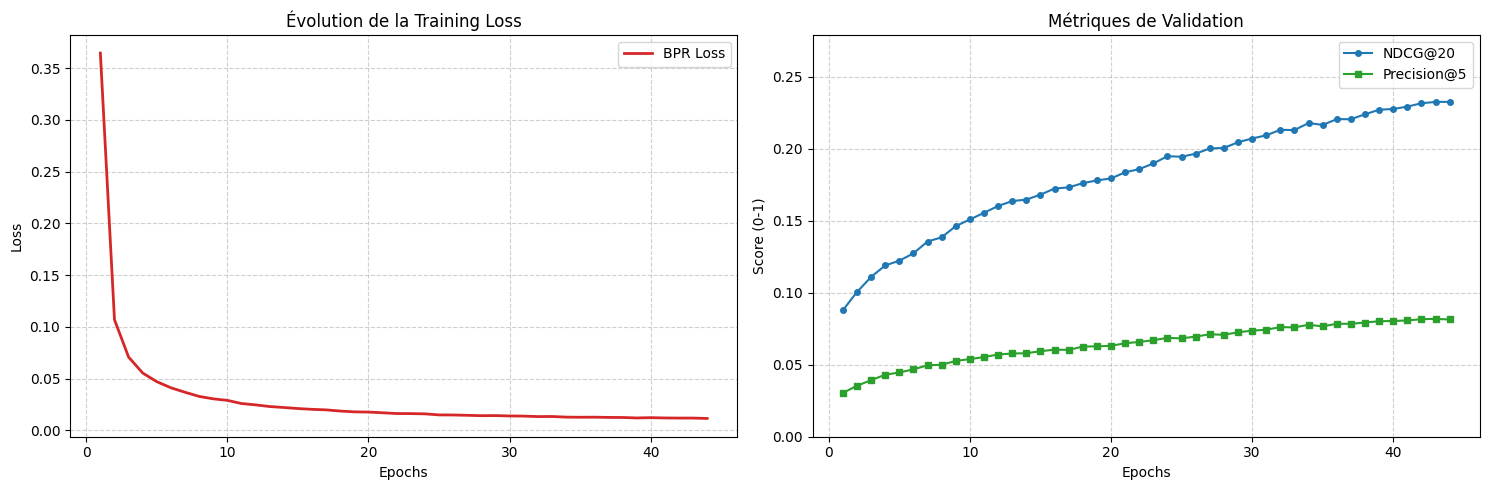

In [ ]:
model = LightGCN_ItemItem(
    adjacency_train,
    E0=None,
    n_layers=2,
    embed_size=256
)

model.load_checkpoint("checkpoints/checkpoint_lgcn_2layer_noInit256.pt", device="cuda")
model.generate_submission_file("checkpoints/checkpoint_lgcn_2layer_noInit256.pt", "soumissions/submission_lgcn_2layer_noInit256.csv")
model.plot_training_curves()

In [ ]:
print(f"Pour LightGCN sans initialisation & dim 256 : \n\n\t > Résultats kaggle : NDCG : {0.20696}\n\t > les courbe de validation étaient très similaire à celle avec initialisation donc je l'ai stoppé plus tôt car les calculs étaient longs")

Pour LightGCN sans initialisation & dim 256 : 

	 > Résultats kaggle : NDCG : 0.20696
	 > les courbe de validation étaient très similaire à celle avec initialisation donc je l'ai stoppé plus tôt car les calculs étaient longs


## 3.3 Discussion

Comme pour la section 2 nous avons fait une sorte de grid search à la main et encore une fois une de nos limites est de ne pas avoir eu le temps d'explorer les variations de `n_layers`.



# 4. RRF + co-citation + bibliographic coupling

## 4.1 Description

Cette méthode combine trois algorithmes différents.

La co-citation : si 2 articles sont cités ensembles, ils sont susceptibles d'être proches sémantiquement. Ainsi, nous pouvons calculer un score à partir du nombre de fois où 2 articles sont co-cités.

Le bibliographic coupling : si 2 articles ont comme référence un même article, ces 2 articles sont suceptibles d'être proches. De la même manière nous pouvons calculer un score ainsi.

Ces deux scores sont en plus pondérés avec l'indice de Adamic-Adar qui permet de donner moins de poids aux références citées très souvent, dans beaucoup d'articles (qui ne permettraient pas de trouver de réelles suggestions pertinentes), et de donner plus de poids aux citations rares. Il faut ajouter 1/log(2 + nbre d'apparitions).

Enfin, plutôt que de pondérer les 2 scores arbitrairement et de les additionner, nous utilisons le reciprocal rank fusion. A partir des deux listes de scores, nous extrayons le rang des articles et nous fusionnons leur rang (qui sont plus comparables). Voici la formule pour calculer le score :
  $RRFScore(d) = \sum_{r \in R} \frac{1}{k + \text{rank}_r(d)}$

  - d : La référence en cours de classement.
  - R : L'ensemble des listes classées.
  - $\text{rank}_r(d)$ : La position de la référence \( d \) dans la liste \( r \) (en commençant à 1).
  - k : Une constante (généralement 60) utilisée pour atténuer l'impact des éléments mal classés.

  En bref, nous choisissons cette approche car elle tire des parties de caractéristiques non utilisées dans les autres approches.

## 4.2 Implémentation

In [35]:
def co_citation(adj, adj_T, direct_refs):
    scores = {}
    for ref_idx in direct_refs:
        co_citers = adj_T[ref_idx].indices
        n_co = len(co_citers)            #pour chaque référence, on compte le nombre de citeurs qui l'ont utilisée
        if n_co == 0:
            continue
        weight = 1.0 / np.log2(n_co + 2)  #calcul du poids dépendant de la rareté de la référence
        for citer in co_citers:           #pour chaque citeur, on ajoute le poids au score des autres citations qu'il fait (i.e. les citations citées en même temps que ref_idx)
            for cand in adj[citer].indices:
                if cand not in direct_refs:
                    scores[cand] = scores.get(cand, 0.0) + weight
    return scores

def bib_coupling(adj, adj_T, direct_refs):
    scores = {}
    for ref_idx in direct_refs:      # pour chaque ref citée
        citers = adj_T[ref_idx].indices
        n_citers = len(citers)
        if n_citers == 0:
            continue
        weight = 1.0 / np.log2(n_citers + 2) #rareté de la citation partagée
        for citer in citers:
            scores[citer] = scores.get(citer, 0.0) + weight  #on actualise le score du citeur
    return scores

def rrf(cc,bc, k=20):
    scores = {}

    #co-citation
    ranked = sorted(cc.items(), key=lambda x: x[1], reverse=True)  #on trie par odre décroissant pour avoir le rang
    for rank, (i, _) in enumerate(ranked, 1):
        scores[i] = scores.get(i, 0.0) + 1.0 / (k + rank)  #actualisation des scores

    #bib-coupling
    ranked = sorted(bc.items(), key=lambda x: x[1], reverse=True)  #on trie par odre décroissant pour avoir le rang
    for rank, (i, _) in enumerate(ranked, 1):
        scores[i] = scores.get(i, 0.0) + 1.0/(k + rank)  #actualisation des scores

    return scores

def recommend_final(idx_to_predict, adjacency, adjacency_T, top_k=20, k_rrf=20):
    idx_to_predict = idx_to_predict-1
    direct_refs = set(adjacency[idx_to_predict].indices.tolist())

    #calcul des différents scores
    cc = co_citation(adjacency, adjacency_T, direct_refs)
    bc = bib_coupling(adjacency, adjacency_T, direct_refs)
    scores = rrf(cc, bc, k=k_rrf)

    # on exclue l'article en question
    scores.pop(idx_to_predict, None)

    # on trie et on récupère les 20 meilleurs
    top20_idx = sorted(scores, key=scores.get, reverse=True)[:top_k]
    return top20_idx

def generate_submission(ids_test, adjacency, adjacency_T, ids, k_rrf):
    results = []
    n_to_id = dict(zip(ids['n'], ids['id'])) #dictionnaire de conversion entre id et n

    for _, row in tqdm(ids_test.iterrows(), total=len(ids_test)):
        test_n = row['idx']  #récupération du n
        test_id = row['id']  #récupération de l'id

        #calcul des recommandations
        top20_n = recommend_final(test_n, adjacency, adjacency_T, k_rrf=k_rrf)
        top20_ids = [n_to_id.get(n + 1, '') for n in top20_n]

        #construction du résultat
        while len(top20_ids) < 20:
            top20_ids.append('')

        results.append({
            'id': test_id,
            'recommandations': ' '.join(top20_ids[:20])
        })

    return pd.DataFrame(results)

## 4.3 Performances

In [43]:
#Première grid search "grossière"
k_grid = [5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100]

ndcg_mean = []
precision_mean = []
adjacency_train_T = adjacency_train.T.tocsr()

for k_rrf in k_grid:
    print(f"k_rrf = {k_rrf}")
    recom = {}
    ndcg_scores = []
    precision_scores = []

    for idx in tqdm(val_indexes_hidden_refs.keys()):
        top20_n = recommend_final(idx, adjacency_train, adjacency_train_T, k_rrf=k_rrf)
        ndcg_scores.append(ndcg(val_indexes_hidden_refs[idx], top20_n))
        precision_scores.append(precision(val_indexes_hidden_refs[idx], top20_n))

    ndcg_mean.append(np.mean(ndcg_scores))
    precision_mean.append(np.mean(precision_scores))

k_rrf = 5


100%|██████████| 281/281 [00:19<00:00, 14.07it/s]


k_rrf = 10


100%|██████████| 281/281 [00:20<00:00, 13.66it/s]


k_rrf = 15


...

100%|██████████| 281/281 [00:19<00:00, 14.69it/s]


k_rrf = 90


100%|██████████| 281/281 [00:19<00:00, 14.36it/s]


k_rrf = 100


100%|██████████| 281/281 [00:19<00:00, 14.46it/s]


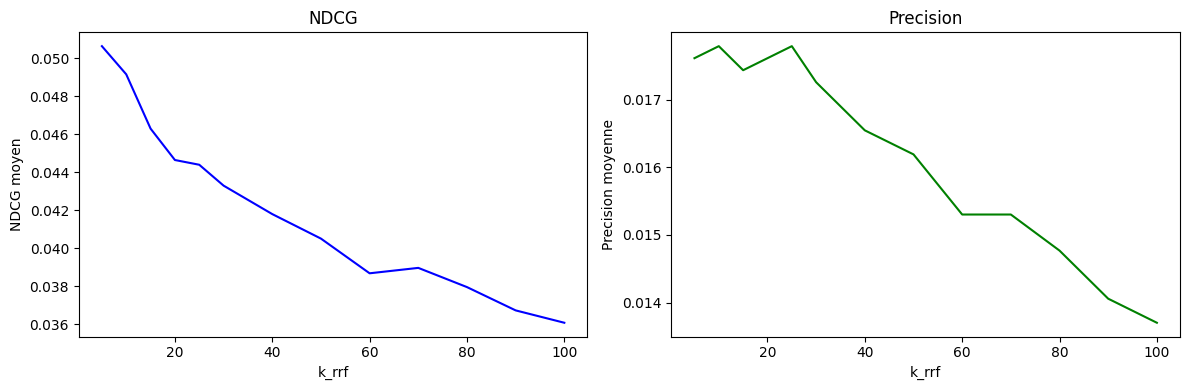

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(k_grid, ndcg_mean, color='b')
ax1.set_xlabel("k_rrf")
ax1.set_ylabel("NDCG moyen")
ax1.set_title("NDCG")

ax2.plot(k_grid, precision_mean, color='g')
ax2.set_xlabel("k_rrf")
ax2.set_ylabel("Precision moyenne")
ax2.set_title("Precision")

plt.tight_layout()
plt.show()

In [45]:
#deuxième grid search plus précise
k_grid = [i for i in range(1,23)]

ndcg_mean = []
precision_mean = []
adjacency_train_T = adjacency_train.T.tocsr()

for k_rrf in k_grid:
    print(f"k_rrf = {k_rrf}")
    recom = {}
    ndcg_scores = []
    precision_scores = []

    for idx in tqdm(val_indexes_hidden_refs.keys()):
        top20_n = recommend_final(idx, adjacency_train, adjacency_train_T, k_rrf=k_rrf)
        ndcg_scores.append(ndcg(val_indexes_hidden_refs[idx], top20_n))
        precision_scores.append(precision(val_indexes_hidden_refs[idx], top20_n))

    ndcg_mean.append(np.mean(ndcg_scores))
    precision_mean.append(np.mean(precision_scores))

k_rrf = 1


100%|██████████| 281/281 [00:19<00:00, 14.42it/s]


k_rrf = 2


100%|██████████| 281/281 [00:19<00:00, 14.20it/s]


k_rrf = 3


...

100%|██████████| 281/281 [00:19<00:00, 14.46it/s]


k_rrf = 21


100%|██████████| 281/281 [00:19<00:00, 14.29it/s]


k_rrf = 22


100%|██████████| 281/281 [00:19<00:00, 14.33it/s]


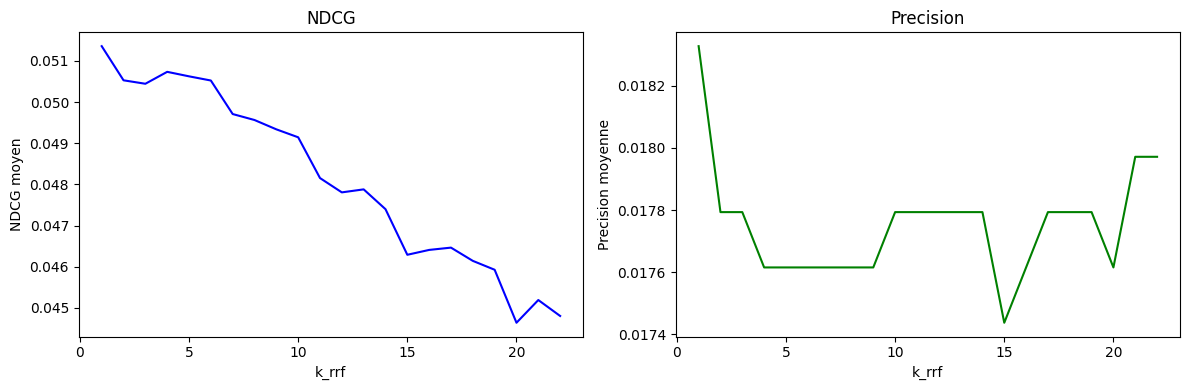

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(k_grid, ndcg_mean, color='b')
ax1.set_xlabel("k_rrf")
ax1.set_ylabel("NDCG moyen")
ax1.set_title("NDCG")

ax2.plot(k_grid, precision_mean, color='g')
ax2.set_xlabel("k_rrf")
ax2.set_ylabel("Precision moyenne")
ax2.set_title("Precision")

plt.tight_layout()
plt.show()

In [47]:
adjacency_T = adjacency.T.tocsr()

submission_final = generate_submission(ids_test, adjacency, adjacency_T, ids, k_rrf=8)
submission_final.to_csv('submissionRRF.csv', index=False)

100%|██████████| 100/100 [00:25<00:00,  3.93it/s]


In [48]:
print("score NDCG kaggle : 0.29704")

score NDCG kaggle : 0.29704


## 4.4 Discussion

Les deux grid search aident à identifier le meilleur k pour le RRF. Le meilleur k est celui qui trouve le meilleur compromis entre précision et NDCG (pas seulement NDCG).
La force de cette méthode est qu'elle tire partie de deux approches (co-citation et bibliographic coupling) et que leur score est fusionné de manière pertinente (RRF plutôt que alpha x score1 + beta x score2).

# 5. Conclusion

| Méthode | NDCG Kaggle |
|---|---|
| PageRank personnalisé | 0.16 |
| NGCF sans initialisation (dim 64) | 0.25 |
| LightGCN + PCA 256 | 0.25 |
| RRF + co-citation + bibliographic coupling | 0.30 |

Nous observons des résultats bien différents selon les techniques employées.

Le Pagerank obtient les moins bons résultats car il a tendance à se ramener aux articles les plus populaires (les plus cités) donc il n'est pas vraiment spécifique aux articles de test. Selon nous, il n'exploite pas suffisament le potentiel des nombreuses données que nous possédons et n'a pas une approche bien adaptée au problème pour atteindre de très bons résultats.

Le NGCF montre une nette amélioration du NDCG. En apprenant les représentations des articles et de leurs voisins via des embeddings, les prédictions peuvent plus facilement se porter sur des articles peut-être moins populaires mais plus pertinents car plus proche de ce que représente l'article initial.

Le LightGCN était plus rapide et globalement meilleur que le NGCF même si dans le tableau ci-dessus cela ne se voit pas car le NGCF à eu un une fois un score anormalement élevé (qui n'a d'ailleurs pas été reproduit ensuite). Peut-être qu'avec un plus long entraînement et tuning des hyperparamètres plus poussé, il pourrait atteindre un score encore meilleur en particulier en augmentant la dimension des embeddings, cependant nous n'avons pas eu le temps de poussé à plus de 256 dimensions.

Enfin, la meilleure solution est obtenue en combinant plusieurs approches (RRF + co-citation + bibliographic coupling) : nous tirons partie de plusieurs manières de représenter la proximité entre des articles, la co-citation et le bibliogtraphic coupling. De plus, le RRF permet d'avoir une fusion plus juste des rangs (plutôt qu'une pondération arbitraire des scores). C'est une solution dont la complexité permet d'exploiter au mieux les données en notre possession en explorant de manière "locale" (citations et co-citations) les articles et c'est pourquoi elle obtient les meilleurs résultats. Cela montre qu'un bon algorithme, prenant en compte plusieurs "paradigmes" bien pensés et adapté à notre problème peut mieux performer qu'un gros modèle nécessitant de longues heures d'entraînement.


En quelques mots, il semblerait que les méthodes explorant le voisinage des articles soient plus pertinentes que celles qui considèrent le dataset de manière globale en tentant d'apprendre des schémas ou de trouver des articles de convergence/populaires.